# Image Classification on CIFAR-10

## Problem Description

The goal of this task is to perform image classification on the [CIFAR-10](https://www.cs.toronto.edu/~kriz/cifar.html) dataset using the [ResNet](https://arxiv.org/pdf/1512.03385.pdf) architecture. CIFAR-10 is a dataset consisting of 60,000 32x32 color images in 10 classes (airplanes, cars, birds, cats, deer, dogs, frogs, horses, ships, and trucks), with 6,000 images per class. The ResNet (Residual Network) is a deep learning architecture known for its ability to train very deep neural networks effectively. We will further explore the problems and solutions encountered in image classification tasks based on the previous assignment. 


## Technical Specifications

* All solutions should be submitted as a modified and compiled copy of this base notebook.
* Do not change cells starting with the `###DO NOT CHANGE THIS CELL###` comment.
* Please allocate your time reasonably, for example, completing other tasks while the model is training.


## Task 1: Image Classification with Pretrained Weights (50 Marks)

In the previous exercises, we explored training a ResNet18 network from scratch on the CIFAR-10 dataset. In this task, we will attempt to fully utilize the advantages of a pre-trained model to reduce training time and improve model accuracy.

The standard training process includes the following steps:
1. Create data augmentation strategies, training sets, and test sets;
2. Define a network architecture and initialize an instance;
3. Create an optimizer that includes all the parameters of the network;
4. Select a loss function for the training process, complete several epochs of training, and test after finishing.

The finetuning process we use here mainly differs in steps two:

2. Define a network architecture, initialize an instance, and load the parameters of a pre-trained model (except for the last linear layer);

We provide the common parts of the code, including the dataset definition, network architecture definition, and the training and evaluation processes. You need to complete the finetuning process according to the instructions.

**Note**: For the network architecture part, you only need to read the **init** function of ResNet to understand the components that make up the entire model. You do not need to read the make_layer function, the forward process, or the specific implementation of the residual block.

In [27]:
###DO NOT CHANGE THIS CELL###
import torch
import torchvision
import torch.optim as optim
import torch.nn as nn
import torch.nn.functional as F
from tqdm import tqdm
import torchvision.transforms as transforms

transform_train = transforms.Compose([
    # Q1.1 line 1
    transforms.RandomCrop(size=(32, 32), padding=4),
    transforms.RandomHorizontalFlip(p=0.5),
    # Q1.1 line 2
    transforms.ToTensor(),
    transforms.Normalize(0.5, 0.5)
])

transform_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(0.5, 0.5)
])

trainset = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform_train)
trainloader = torch.utils.data.DataLoader(trainset, batch_size=128, shuffle=True, num_workers=0)

testset = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=transform_test)
testloader = torch.utils.data.DataLoader(testset, batch_size=100, shuffle=False, num_workers=0)
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(device)


class BasicBlock(nn.Module):

    def __init__(self, inplanes, planes, stride=1, track_running_stats=False):
        super().__init__()
        # Both self.conv1 and self.downsample layers downsample the input when stride != 1
        self.conv1 = nn.Conv2d(inplanes, planes, kernel_size=3, stride=stride, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(planes, track_running_stats=track_running_stats)
        self.relu = nn.ReLU(inplace=True)
        self.conv2 = nn.Conv2d(planes, planes, kernel_size=3, stride=1, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(planes, track_running_stats=track_running_stats)
        if stride != 1:
            self.downsample = nn.Sequential(
                nn.Conv2d(inplanes, planes, kernel_size=1, stride=stride, bias=False),
                nn.BatchNorm2d(planes),
            )
        else:
            self.downsample = None

    def forward(self, x):
        identity = x
        out = self.conv1(x)
        out = self.bn1(out)
        out = self.relu(out)
        out = self.conv2(out)
        out = self.bn2(out)
        if self.downsample is not None:
            identity = self.downsample(x)
        out += identity
        out = self.relu(out)
        return out


class ResNet(nn.Module):
    def __init__(self, num_classes=10, track_running_stats=False):
        super(ResNet, self).__init__()
        self.inchannel = 64
        self.conv1 = nn.Conv2d(3, 64, kernel_size=7, stride=1, padding=3, bias=False)
        self.bn1 = nn.BatchNorm2d(64, track_running_stats=track_running_stats)
        self.relu = nn.ReLU(inplace=True)
        self.layer1 = self.make_layer(BasicBlock, 64, 2, stride=1, track_running_stats=track_running_stats)
        self.layer2 = self.make_layer(BasicBlock, 128, 2, stride=2, track_running_stats=track_running_stats)
        self.layer3 = self.make_layer(BasicBlock, 256, 2, stride=2, track_running_stats=track_running_stats)
        self.layer4 = self.make_layer(BasicBlock, 512, 2, stride=2, track_running_stats=track_running_stats)
        self.fc = nn.Linear(512, num_classes)

    def make_layer(self, block, channels, num_blocks, stride, track_running_stats):
        strides = [stride] + [1] * (num_blocks - 1)
        layers = []
        for stride in strides:
            layers.append(block(self.inchannel, channels, stride, track_running_stats))
            self.inchannel = channels
        return nn.Sequential(*layers)

    def forward(self, x):
        out = self.conv1(x)
        out = self.bn1(out)
        out = self.relu(out)
        out = self.layer1(out)
        out = self.layer2(out)
        out = self.layer3(out)
        out = self.layer4(out)
        out = F.avg_pool2d(out, 4)
        out = out.view(out.size(0), -1)
        out = self.fc(out)
        return out

def train(model, optimizer, trainloader, num_epochs=1, criterion=torch.nn.functional.cross_entropy):
    criterion = torch.nn.functional.cross_entropy
    for epoch in range(num_epochs):
        running_loss = 0.0
        for i, data in enumerate(tqdm(trainloader)):
            inputs, labels = data
            inputs = inputs.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()

            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            # print statistics
            running_loss += loss.item()
            if i % 100 == 99:
                print(f"epoch: {epoch + 1}, step: {i + 1:5d}, loss: {running_loss / 100:.3f}")
                running_loss = 0.0

    print("Finished Training")

def eval(model, testloader):
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for data in tqdm(testloader):
            images, labels = data
            images = images.to(device)
            labels = labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    print(f"Accuracy of the network on the 10000 test images: {100 * correct / total:.1f} %")

Files already downloaded and verified
Files already downloaded and verified
cpu


#### Q1.1 Complete Finetuning Process (4 marks)

Here we need to load the ResNet18 model pre-trained on ImageNet provided by torchvision. Since the number of classes in ImageNet is 1000 and in CIFAR-10 it is 10, we need to remove the last linear layer when loading the pre-trained parameters. After training, we will test the accuracy of the model.

**Deliverables**:

* code
* model accuracy on the test set (should be ~88%)

In [50]:
from torchvision.models import resnet18, ResNet18_Weights


def get_model():
    model = ResNet().to(device)
    weights = ResNet18_Weights.IMAGENET1K_V1
    net = resnet18(weights=weights)

    state_dict = {}
    
    ### START CODE HERE ###
    
    # TODO: load pretrained weights from `net` to `model`. You may load all pretrained weights except for the last linear layer
    # traverse all (key, value) pairs in `net.state_dict()`
    # if 'fc' is the prefix of key, ignore
    # otherwise, add it into `state_dict` (≈3 lines)
    for k, v in net.state_dict().items():
        if 'fc' not in k:
            state_dict[k] = v

    # TODO: load `state_dict` to `model`, remember to use parameter `strict=False` (≈1 line)
    model.load_state_dict(state_dict, strict=False)
    ### END CODE HERE ###
    
    return model

In [16]:
###DO NOT CHANGE THIS CELL###

model = get_model()
parameters = model.parameters()
optimizer = optim.SGD(parameters, lr=0.01, momentum=0.9, weight_decay=5e-4)
train(model, optimizer, trainloader)
eval(model, testloader)

 26%|██▌       | 100/391 [00:57<02:49,  1.72it/s]

epoch: 1, step:   100, loss: 0.953


 51%|█████     | 200/391 [01:54<01:50,  1.73it/s]

epoch: 1, step:   200, loss: 0.477


 77%|███████▋  | 300/391 [02:52<00:53,  1.71it/s]

epoch: 1, step:   300, loss: 0.386


100%|██████████| 391/391 [03:45<00:00,  1.74it/s]


Finished Training


100%|██████████| 100/100 [00:15<00:00,  6.61it/s]

Accuracy of the network on the 10000 test images: 88 %


#### Q1.2 Compare Finetuning and Training from Strach (3 marks)

In this task, we need to train a model without loading pre-trained weights, compare the accuracy of the two models, and discuss what you think are the advantages (and disadvantages) of finetuning.

**Deliverables**:

* code
* model accuracy on the test set (should be ~55%)
* a report of up to 200 words

In [17]:
### START CODE HERE ###
# TODO: train a model from scratch and print the evaluation results  (≈5 lines)
model = ResNet().to(device)
parameters = model.parameters()
optimizer = optim.SGD(parameters, lr=0.01, momentum=0.9, weight_decay=5e-4)
train(model, optimizer, trainloader)
eval(model, testloader)
### END CODE HERE ###

 26%|██▌       | 100/391 [00:55<02:43,  1.78it/s]

epoch: 1, step:   100, loss: 1.824


 51%|█████     | 200/391 [01:51<01:47,  1.77it/s]

epoch: 1, step:   200, loss: 1.545


 77%|███████▋  | 300/391 [02:48<00:51,  1.77it/s]

epoch: 1, step:   300, loss: 1.377


100%|██████████| 391/391 [03:40<00:00,  1.77it/s]


Finished Training


100%|██████████| 100/100 [00:15<00:00,  6.64it/s]

Accuracy of the network on the 10000 test images: 57 %


Finetuning vs. Training 

[Describe your opinion in up to 200 words here.]

#### Q1.3 Use CLIP for Zero-shot Image Classification (8 marks)

When using pre-trained models obtained from image classification datasets like ImageNet for downstream tasks, we often need to fine-tune the model to adapt to the label types in the new dataset. However, with text-image contrastive learning models, we can skip the additional training and directly apply the corresponding model to the classification task of the new dataset. In this experiment, we will use [CLIP](https://github.com/openai/CLIP) as our subject. You need to complete the code as prompted to enable CLIP to perform the evaluation.

The code below performs zero-shot prediction using CLIP. This example takes an image from the CIFAR-100 dataset, and predicts the most likely labels among the 100 textual labels from the dataset. You need to refer to this code to implement the accuracy test of CLIP on CIFAR-10.

```
import os
import clip
import torch
from torchvision.datasets import CIFAR100

# Load the model
device = "cuda" if torch.cuda.is_available() else "cpu"
model, preprocess = clip.load('ViT-B/32', device)

# Download the dataset
cifar100 = CIFAR100(root=os.path.expanduser("~/.cache"), download=True, train=False)

# Prepare the inputs
image, class_id = cifar100[3637]
image_input = preprocess(image).unsqueeze(0).to(device)
text_inputs = torch.cat([clip.tokenize(f"a photo of a {c}") for c in cifar100.classes]).to(device)

# Calculate features
with torch.no_grad():
    image_features = model.encode_image(image_input)
    text_features = model.encode_text(text_inputs)

# Pick the top 5 most similar labels for the image
image_features /= image_features.norm(dim=-1, keepdim=True)
text_features /= text_features.norm(dim=-1, keepdim=True)
similarity = (100.0 * image_features @ text_features.T).softmax(dim=-1)
values, indices = similarity[0].topk(5)

# Print the result
print("\nTop predictions:\n")
for value, index in zip(values, indices):
    print(f"{cifar100.classes[index]:>16s}: {100 * value.item():.2f}%")
```


**Deliverables**:

* code
* model accuracy on the test set (should be ~90%)

In [70]:
!pip3 install openai-clip

     ---------------------------------------- 0.0/1.4 MB ? eta -:--:--
     --- ------------------------------------ 0.1/1.4 MB 2.4 MB/s eta 0:00:01
     -------------------- ------------------- 0.7/1.4 MB 7.4 MB/s eta 0:00:01
     ------------------------------------- -- 1.3/1.4 MB 9.0 MB/s eta 0:00:01
     ---------------------------------------- 1.4/1.4 MB 8.7 MB/s eta 0:00:00
  Preparing metadata (setup.py): started
  Preparing metadata (setup.py): finished with status 'done'
     ---------------------------------------- 0.0/42.0 kB ? eta -:--:--
     ---------------------------------------- 42.0/42.0 kB 2.1 MB/s eta 0:00:00
   ---------------------------------------- 0.0/54.4 kB ? eta -:--:--
   ---------------------------------------- 54.4/54.4 kB ? eta 0:00:00
   ---------------------------------------- 0.0/269.0 kB ? eta -:--:--
   --------------------------------------- 269.0/269.0 kB 16.2 MB/s eta 0:00:00
  Created wheel for openai-clip: filename=openai_clip-1.0.1-py3-none-an

In [2]:
import os
import clip
import torch
from torchvision.datasets import CIFAR10
from tqdm import tqdm
import numpy as np


# Load the model
device = "cuda" if torch.cuda.is_available() else "cpu"
model, preprocess = clip.load('ViT-B/32', device)

# Download the dataset
cifar10 = CIFAR10(root=os.path.expanduser("./data"), download=True, train=False)

correct = 0
total = 0

for image, class_id in tqdm(cifar10):
    # To speed up the evaluation, here we only evaluate on 1/100 testset
    if np.random.randint(100) > 0:
        continue
    
    ### START CODE HERE ###
    # TODO: prepare `image_input` and `text_input` (≈2 lines)
    image_input = preprocess(image).unsqueeze(0).to(device)
    text_inputs = torch.cat([clip.tokenize(f"a photo of a {c}") for c in cifar10.classes]).to(device)

    # TODO: calculate `image_features` and `text_features` (≈3 lines)
    with torch.no_grad():
        image_features = model.encode_image(image_input)
        text_features = model.encode_text(text_inputs)

    # TODO: normalize features and get the prediction label (≈4 lines)
    image_features /= image_features.norm(dim=-1, keepdim=True)
    text_features /= text_features.norm(dim=-1, keepdim=True)
    similarity = (100.0 * image_features @ text_features.T).softmax(dim=-1)
    values, indices = similarity[0].topk(1)
    
    # TODO: update `total` and `correct` accordingly (≈3 lines)
    total += 1
    if indices[0] == class_id:
        correct += 1
    ### END CODE HERE ###
    if total > 100:
        break
print(f"Accuracy of the network on the 10000 test images: {100 * correct // total} %")
        

Files already downloaded and verified


100%|██████████| 10000/10000 [00:36<00:00, 277.50it/s]

Accuracy of the network on the 10000 test images: 83 %


#### Q1.4 Text Prompting for CLIP (10 marks)

In the example we provided, the text for each category is not directly the corresponding word, but rather a constructed sentence 'a photo of a {category_name}', as shown in the line of code below.

```
text_inputs = torch.cat([clip.tokenize(f"a photo of a {c}") for c in cifar100.classes]).to(device)
```

In this task, you need to read Section 3.1.4 of the [original CLIP paper](https://github.com/openai/CLIP) and implement the ensemble method for the prompts:
```
itap of a {}.
a bad photo of the {}.
a origami {}.
a photo of the large {}.
a {} in a video game.
art of the {}.
a photo of the small {}.
```

Report the accuracy and discuss why this ensemble method has a better performance than a single prompt.


**Deliverables**:

* code
* model accuracy on the test set (should be ~91%)
* a report of up to 200 words


In [10]:
correct = 0
total = 0

for image, class_id in tqdm(cifar10):
    # To speed up the evaluation, here we only evaluate on 1/100 testset
    if np.random.randint(100) > 0:
        continue
    ### START CODE HERE ###
    # TODO: use prompt 'a {c}' to extract text feature and get prediction results (≈25 lines)

    image_input = preprocess(image).unsqueeze(0).to(device)
    text_inputs1 = torch.cat([clip.tokenize(f"itap of a {c}") for c in cifar10.classes]).to(device)
    text_inputs2 = torch.cat([clip.tokenize(f"a bad photo of the {c}") for c in cifar10.classes]).to(device)
    text_inputs3 = torch.cat([clip.tokenize(f"a origami {c}") for c in cifar10.classes]).to(device)
    text_inputs4 = torch.cat([clip.tokenize(f"a photo of the large {c}") for c in cifar10.classes]).to(device)
    text_inputs5 = torch.cat([clip.tokenize(f"a {c} in a video game") for c in cifar10.classes]).to(device)
    text_inputs6 = torch.cat([clip.tokenize(f"art of the {c}") for c in cifar10.classes]).to(device)
    text_inputs7 = torch.cat([clip.tokenize(f"a photo of the small {c}") for c in cifar10.classes]).to(device)
    with torch.no_grad():
        image_features = model.encode_image(image_input)
        text_features1 = model.encode_text(text_inputs1)
        text_features2 = model.encode_text(text_inputs2)
        text_features3 = model.encode_text(text_inputs3)
        text_features4 = model.encode_text(text_inputs4)
        text_features5 = model.encode_text(text_inputs5)
        text_features6 = model.encode_text(text_inputs6)
        text_features7 = model.encode_text(text_inputs7)
        text_features = (text_features1 + text_features2 + text_features3 + text_features4 + text_features5 + text_features6 + text_features7) / 7
        
    image_features /= image_features.norm(dim=-1, keepdim=True)
    text_features /= text_features.norm(dim=-1, keepdim=True)
    similarity = (100.0 * image_features @ text_features.T).softmax(dim=-1)
    values, indices = similarity[0].topk(1)
    total += 1
    if indices[0] == class_id:
        correct += 1
    ### END CODE HERE ###
    if total > 100:
        break


print(f"Accuracy of the network on the 10000 test images: {100 * correct // total} %")
        


 87%|████████▋ | 8690/10000 [03:52<00:35, 37.34it/s]

Accuracy of the network on the 10000 test images: 91 %


Single Prompt vs. Prompt Ensemble 

[Describe your opinion in up to 200 words here.]

#### Q1.5 Finetune CLIP on CIFAR-10 (25 marks)

In the previous problem, we found that different prompt strategies have some impact on experimental accuracy. By manually designing prompts and using the ensemble method, we achieved good performance with CLIP in a zero-shot scenario. In this task, you need to implement learnable text features and fine-tune them on the CIFAR-10 training set using a method similar to Q1.1 to improve the model's performance.

Specifically, you will need to complete the following steps:

1. Image feature preprocessing. Since the CLIP model is large, involving it in computation during the finetuning process would be too time-consuming. Therefore, we first need to preprocess all features with CLIP for easier subsequent use. To improve the speed of feature extraction, you cannot process images one at a time as in Q1.3. Instead, you need to forward batches of 16 images at once to enhance the efficiency of feature extraction. Or you can finetune on a subset to reduce the time cost.
2. Create a dataset and data loader. The `__getitem__` function of the dataset should return the image feature and label for each corresponding image. You should also change the transformation functions correspondingly.
3. Create a Module class, initializing learnable text features for each category. Note that the intialization is important. During the forward process, use the input image feature and these category vectors to calculate similarities, yielding confidence levels for each category. Please refer to the [source code](https://github.com/openai/CLIP/blob/main/clip/model.py) of CLIP about the usage of `self.logit_scale`.
4. Adjust various hyperparameters (optimizer, learning rate, batch size, num of epochs) or initialization strategies to try to achieve higher accuracy.

**Deliverables**:

* code (10 marks)
* model accuracy on the test set (10 marks)
* a report of up to 200 words on the design of your approach (5 marks)

**Note**:

1. If you are unable to successfully implement the finetuning process, we will score based on the functionalities you have completed, and you can receive up to 10 points for the code portion. If it runs completely and achieves normal accuracy, you will receive the full 10 points.
2. Assume your accuracy is $acc$, your relative ranking is $i$, and there are $N$ total competitors. Then, your score for the accuracy part would be $\max\{\min\{\frac{acc-91}{96}, 1.0\}*10.0, \frac{i}{N} * 10.0\}$


In [40]:
### START CODE HERE ###
cifar10_train = CIFAR10(root=os.path.expanduser("./data"), download=True, train=True)
image_features_train = []
clip_model, preprocess = clip.load('ViT-B/32', device)
batches = []
for image, class_id in tqdm(cifar10_train):
    image_input = preprocess(image).to(device)
    batches.append(image_input)
    if len(batches) == 100:
        batches = torch.stack(batches, dim=0)
        with torch.no_grad():
            image_feature = clip_model.encode_image(batches)
        image_features_train.append(image_feature)
        batches = []
image_features_train = torch.cat(image_features_train, dim=0)

cifar10_test = CIFAR10(root=os.path.expanduser("./data"), download=True, train=False)
image_features_test = []

batches = []
for image, class_id in tqdm(cifar10_test):
    image_input = preprocess(image).to(device)
    batches.append(image_input)
    if len(batches) == 100:
        batches = torch.stack(batches, dim=0)
        with torch.no_grad():
            image_feature = clip_model.encode_image(batches)
        image_features_test.append(image_feature)
        batches = []
image_features_test = torch.cat(image_features_test, dim=0)
### END CODE HERE ###

Files already downloaded and verified


100%|██████████| 50000/50000 [12:50<00:00, 64.92it/s]


Files already downloaded and verified


100%|██████████| 10000/10000 [02:40<00:00, 62.47it/s]


In [47]:
### START CODE HERE ###
class FTDataset(CIFAR10):
    def __init__(self, image_features, **kwargs):
        super().__init__(**kwargs)
        self.image_features = image_features
        
    def __getitem__(self, index):
        image_feature = self.image_features[index]
        image, label = super().__getitem__(index)
        return image_feature, label
    

class FTModule(nn.Module):
    
    def __init__(self):
        super().__init__()
        text_inputs1 = torch.cat([clip.tokenize(f"itap of a {c}") for c in cifar10.classes]).to(device)
        text_inputs2 = torch.cat([clip.tokenize(f"a bad photo of the {c}") for c in cifar10.classes]).to(device)
        text_inputs3 = torch.cat([clip.tokenize(f"a origami {c}") for c in cifar10.classes]).to(device)
        text_inputs4 = torch.cat([clip.tokenize(f"a photo of the large {c}") for c in cifar10.classes]).to(device)
        text_inputs5 = torch.cat([clip.tokenize(f"a {c} in a video game") for c in cifar10.classes]).to(device)
        text_inputs6 = torch.cat([clip.tokenize(f"art of the {c}") for c in cifar10.classes]).to(device)
        text_inputs7 = torch.cat([clip.tokenize(f"a photo of the small {c}") for c in cifar10.classes]).to(device)
        
        clip_model, _ = clip.load('ViT-B/32', device)
        with torch.no_grad():
            text_features1 = clip_model.encode_text(text_inputs1)
            text_features2 = clip_model.encode_text(text_inputs2)
            text_features3 = clip_model.encode_text(text_inputs3)
            text_features4 = clip_model.encode_text(text_inputs4)
            text_features5 = clip_model.encode_text(text_inputs5)
            text_features6 = clip_model.encode_text(text_inputs6)
            text_features7 = clip_model.encode_text(text_inputs7)
        text_features = (text_features1 + text_features2 + text_features3 + text_features4 + text_features5 + text_features6 + text_features7) / 7.0
        self.param = nn.Parameter(text_features)
        self.logit_scale = nn.Parameter(torch.ones([]) * np.log(1 / 0.07))
    
    def forward(self, image_features):
        if self.training:
            mask = (torch.rand(1, 512) < 0.5).float().to(device)
        else:
            mask = torch.ones(1, 512).to(device)
        param = self.param * mask
        image_features = image_features * mask
        param = param / param.norm(dim=-1, keepdim=True)
        image_features = image_features / image_features.norm(dim=-1, keepdim=True)
        similarity = image_features @ param.T
        return similarity * self.logit_scale.exp()

transform_ft = transforms.Compose([
    transforms.ToTensor()
])
cifar10_train_ft = FTDataset(image_features_train, root=os.path.expanduser("./data"), download=True, train=True, transform=transform_ft)
cifar10_test_ft = FTDataset(image_features_test, root=os.path.expanduser("./data"), download=True, train=False, transform=transform_ft)
trainloader_ft = torch.utils.data.DataLoader(cifar10_train_ft, batch_size=128, shuffle=True, num_workers=0)
testloader_ft = torch.utils.data.DataLoader(cifar10_test_ft, batch_size=100, shuffle=False, num_workers=0)
model = FTModule().to(device)
parameters = model.parameters()
optimizer = optim.Adam(parameters, lr=0.01)
train(model, optimizer, trainloader_ft, num_epochs=5)
eval(model, testloader_ft)
### END CODE HERE ###

Files already downloaded and verified
Files already downloaded and verified


 27%|██▋       | 107/391 [00:01<00:04, 66.34it/s]

epoch: 1, step:   100, loss: 0.643


 54%|█████▎    | 210/391 [00:03<00:02, 66.08it/s]

epoch: 1, step:   200, loss: 0.284


...

epoch: 5, step:   300, loss: 0.218


100%|██████████| 391/391 [00:06<00:00, 64.20it/s]


Finished Training


100%|██████████| 100/100 [00:01<00:00, 86.13it/s]

Accuracy of the network on the 10000 test images: 94.3 %


Method Design

[Describe your method in up to 200 words here.]

## Task 2: Image Classification under Imbalanced Distribution (50 Marks)

In the actual process of data collection and training deep learning models, we often encounter scenarios with imbalanced data distribution. For example, in image classification tasks, pandas appear far less frequently than cats and dogs, which can result in significant differences in our model's classification performance across different categories. In this task, we will create an imbalanced training set on CIFAR-10 and explore different methods to improve the model's performance.

#### Q2.1 Create Imbalanced Training Set and Train A Baseline Model (5 marks)

In this task, we need to create an imbalanced training set based on CIFAR-10. We will create a new dataset inheriting from `torchvision.datasets.CIFAR10`. After the standard initialization, we will delete some images to simulate the imbalanced data distribution that occurs in the real world. Once the dataset is established, we will use the method from Q1.1 to train a baseline model.

**Deliverables**:

* code
* model accuracy on the test set (should be ~69%)

In [51]:
import pickle
import os
import numpy as np

class ImbalancedCIFAR10(torchvision.datasets.CIFAR10):
    
    def __init__(self, root, train=True, transform=None, target_transform=None, download=False):
        super(ImbalancedCIFAR10, self).__init__(
            root, train=train, transform=transform, target_transform=target_transform, download=download)
        
        new_data = []
        new_targets = []
        keep_ratio = [1.0, 1.0, 0.5, 0.5, 0.25, 0.25, 0.1, 0.1, 0.02, 0.02]
        num_data = len(self.data)
        print("Num Data:" + str(num_data))
        ### START CODE HERE ###
        # TODO: Randomly remove images and corresponding targets (≈5 lines)
        # For each image in category `i`, the keep ratio is `keep_ratio[i]`
        # self.data: numpy array, (N, 3, 32, 32)
        # self.targets: list, (N)
        for i in range(num_data):
            cid = self.targets[i]
            if np.random.random() < keep_ratio[cid]:
                new_data.append(self.data[i])
                new_targets.append(self.targets[i])
        ### END CODE HERE ###
        self.data = new_data
        self.targets = new_targets
        assert len(self.data) == len(self.targets)
        self.data = np.stack(self.data, axis=0)
        print(self.data.shape)
        num_dist = [0 for _ in range(10)]
        for i in self.targets:
            num_dist[i] += 1
        print(num_dist)
        print("Num Data:" + str(len(self.data)))


### START CODE HERE ###
# TODO: initialize an imbalanced dataset and the corresponding dataloader
# train a model with pretrained weight as in Q1.1 and print the evaluation results
# to avoid unexpected error of the dataloader, we suggest you to use `num_workers=0`
# the number of iterations in each epoch is reduced to around 1/3. Thus you should train 3 epochs for a fair comparison. (≈7 lines)
imbalanced_trainset = ImbalancedCIFAR10(root='./data', train=True, download=True, transform=transform_train)
imbalanced_trainloader = torch.utils.data.DataLoader(imbalanced_trainset, batch_size=128, shuffle=True, num_workers=0)
model = get_model()
parameters = model.parameters()
optimizer = optim.SGD(parameters, lr=0.01, momentum=0.9, weight_decay=5e-4)
train(model, optimizer, imbalanced_trainloader, num_epochs=3)
eval(model, testloader)
### END CODE HERE ###

Files already downloaded and verified
Num Data:50000
(18901, 32, 32, 3)
[5000, 5000, 2524, 2561, 1297, 1295, 489, 520, 118, 97]
Num Data:18901


 68%|██████▊   | 100/148 [00:59<00:29,  1.63it/s]

epoch: 1, step:   100, loss: 0.813


 68%|██████▊   | 100/148 [00:59<00:28,  1.68it/s]

epoch: 2, step:   100, loss: 0.310


...

epoch: 3, step:   100, loss: 0.204


100%|██████████| 148/148 [01:28<00:00,  1.67it/s]


Finished Training


100%|██████████| 100/100 [00:15<00:00,  6.37it/s]

Accuracy of the network on the 10000 test images: 70.3 %


#### Q2.2 Report Performance on Each Category (12 marks)

We obtained an accuracy much lower than that of Q1.1, ~69%. In real situations, when we encounter low training accuracy in a model, we can perform more detailed validation and analysis to try to identify which types of inputs the model is not performing well on. In this task, you need to implement a new evaluation function that outputs the model's **Precision** and **Recall** for each category. Additionally, we will output a confusion matrix. Please discuss the impact of data distribution on model accuracy based on the obtained information.

**Note**: 
1. A true positive(TP) is an outcome where the model correctly predicts the positive class. Similarly, a true negative(TN) is an outcome where the model correctly predicts the negative class.
2. A false positive(FP) is an outcome where the model incorrectly predicts the positive class. And a false negative(FN) is an outcome where the model incorrectly predicts the negative class. 
3. $\textrm{Precision}=\frac{TP}{TP+FP},\textrm{Recall}=\frac{TP}{TP+FN}$ 

**Deliverables**:

* code
* recall and precision on the test set
* a report of up to 300 words


In [6]:
def eval_category(model, testloader):
    model.eval()
    ### START CODE HERE ###
    # TODO: initialize TP, FP, FN counters for each category. CIFAR-10 has ten categories in total. (≈3 lines)
    TP = np.zeros(10)
    FP = np.zeros(10)
    FN = np.zeros(10)
    ### END CODE HERE ###
    with torch.no_grad():
        for data in tqdm(testloader):
            images, labels = data
            images = images.to(device)
            labels = labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs.data, 1)
            ### START CODE HERE ###
            # TODO: traverse each sample in current batch and update counters (≈9 lines)
            num_data = len(labels)
            for i in range(num_data):
                pred = predicted[i]
                label = labels[i]
                if pred == label:
                    TP[label] += 1
                else:
                    FP[pred] += 1
                    FN[label] += 1
            
    # TODO: calculate and print Precision and Recall for each category (≈5 lines)
    precision = 100 * TP // (TP + FP)
    recall = 100 * TP // (TP + FN)
    for i in range(10):
        print(f"Precision of category {i}: {precision[i]} %")
        print(f"Recall of category {i}: {recall[i]} %")
        
    ### END CODE HERE ###
    
eval_category(model, testloader)

100%|██████████| 100/100 [00:14<00:00,  6.85it/s]

Precision of category 0: 53.0 %
Recall of category 0: 97.0 %
Precision of category 1: 44.0 %
Recall of category 1: 99.0 %
Precision of category 2: 71.0 %
Recall of category 2: 90.0 %
Precision of category 3: 70.0 %
Recall of category 3: 76.0 %
Precision of category 4: 89.0 %
Recall of category 4: 74.0 %
Precision of category 5: 87.0 %
Recall of category 5: 72.0 %
Precision of category 6: 97.0 %
Recall of category 6: 66.0 %
Precision of category 7: 93.0 %
Recall of category 7: 74.0 %
Precision of category 8: 100.0 %
Recall of category 8: 25.0 %
Precision of category 9: 98.0 %
Recall of category 9: 21.0 %


**Confusion Matrix** is a table that is used in classification problems to assess where errors in the model were made. The rows represent the actual classes the outcomes should have been. While the columns represent the predictions we have made. Using this table it is easy to see which predictions are wrong.

In [8]:
!pip3 install scikit-learn

     ---------------------------------------- 0.0/60.6 kB ? eta -:--:--
     --------------------------------- ------ 51.2/60.6 kB 2.7 MB/s eta 0:00:01
     ---------------------------------------- 60.6/60.6 kB 1.6 MB/s eta 0:00:00
   ---------------------------------------- 0.0/11.0 MB ? eta -:--:--
   - -------------------------------------- 0.5/11.0 MB 14.9 MB/s eta 0:00:01
   --- ------------------------------------ 0.9/11.0 MB 11.7 MB/s eta 0:00:01
   ------ --------------------------------- 1.8/11.0 MB 14.4 MB/s eta 0:00:01
   ---------- ----------------------------- 3.0/11.0 MB 17.3 MB/s eta 0:00:01
   --------------- ------------------------ 4.3/11.0 MB 19.8 MB/s eta 0:00:01
   --------------------- ------------------ 5.9/11.0 MB 22.2 MB/s eta 0:00:01
   ---------------------------- ----------- 7.9/11.0 MB 25.1 MB/s eta 0:00:01
   ------------------------------------ --- 9.9/11.0 MB 27.6 MB/s eta 0:00:01
   ---------------------------------------- 11.0/11.0 MB 31.2 MB/s eta 0:0

100%|██████████| 100/100 [00:14<00:00,  6.92it/s]


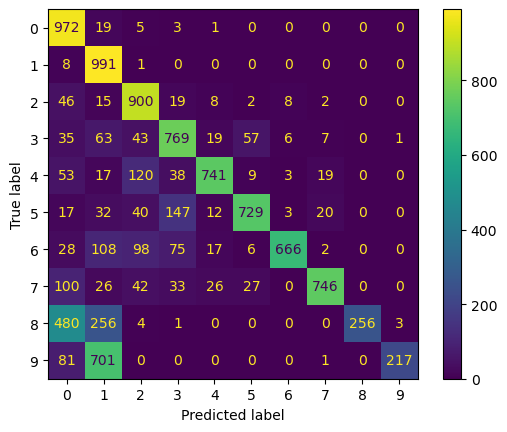

In [12]:
###DO NOT CHANGE THIS CELL###
from sklearn import metrics
import matplotlib.pyplot as plt


def show_confusion_matrix(model, testloader):
    model.eval()
    preds = []
    targets = []
    with torch.no_grad():
        for data in tqdm(testloader):
            images, labels = data
            images = images.to(device)
            labels = labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs.data, 1)
            preds.append(predicted.numpy())
            targets.append(labels.numpy())
    preds = np.concatenate(preds, axis=0)
    targets = np.concatenate(targets, axis=0)
    confusion_matrix = metrics.confusion_matrix(targets, preds)
    cm_display = metrics.ConfusionMatrixDisplay(confusion_matrix = confusion_matrix, display_labels = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9])
    cm_display.plot()
    plt.show()
    
show_confusion_matrix(model, testloader)

How does imbalanced distribution affect the model's performance on each category? What is its impact on Precision and Recall, and what could be the reasons?

[Describe your findings and analysis in up to 300 words here.]

#### Q2.3 Balanced Sampling (6 marks)

In the previous problem, we found that when the training set is imbalanced, the model performs very poorly on a balanced test set. In this task, we will try to solve the above problem using a simple balanced sampling method. The core steps of this balanced method are as follows:

1. During dataset initialization, store each image in a different list according to its category.
2. In `__getitem__`, first randomly select a category with equal probability, and then randomly select an index from the list corresponding to this category with equal probability as the image index to be used for this sample.

You need to complete the corresponding code for this dataset based on the prompts, and then use the training method from Q1.1 to train the model. Afterward, use the provided `eval`, `show_confusion_matrix`, and your own `eval_category` functions for data analysis.

**Deliverables**:

* code
* recall and precision on the test set

In [52]:
class BalancedSamplingDataset(ImbalancedCIFAR10):
    
    def __init__(self, **kwargs):
        super().__init__(**kwargs)
        
        ### START CODE HERE ### 
        # TODO: store each image in a different list according to its category (≈4 lines)
        self.index_per_class = [[] for _ in range(10)]
        for i in range(len(self.data)):
            cid = self.targets[i]
            self.index_per_class[cid].append(i)
        ### END CODE HERE ###
        
    def __getitem__(self, index):
        ### START CODE HERE ###
        # TODO: 1) randomly select a category with equal probability (≈3 lines)
        # 2) randomly select an `index`` from the list corresponding to this category with equal probability
        cid = np.random.randint(10)
        index = np.random.choice(len(self.index_per_class[cid]))
        index = self.index_per_class[cid][index]
        ### END CODE HERE ###
        
        return super().__getitem__(index)

### START CODE HERE ###
# TODO: train the model using the same strategy as Q1.1 and then evaluate the performance (≈9 lines)
# remember to use `eval`, `eval_category` and `show_confusion_matrix`
balanced_trainset = BalancedSamplingDataset(root='./data', train=True, download=True, transform=transform_train)
balanced_trainloader = torch.utils.data.DataLoader(balanced_trainset, batch_size=128, shuffle=True, num_workers=0)
model = get_model()
parameters = model.parameters()
optimizer = optim.SGD(parameters, lr=0.01, momentum=0.9, weight_decay=5e-4)
train(model, optimizer, balanced_trainloader, num_epochs=3)
eval(model, testloader)
eval_category(model, testloader)
show_confusion_matrix(model, testloader)
### END CODE HERE ###

Files already downloaded and verified
Num Data:50000
(18670, 32, 32, 3)
[5000, 5000, 2460, 2553, 1199, 1256, 521, 491, 85, 105]
Num Data:18670


 68%|██████▊   | 100/146 [00:58<00:26,  1.72it/s]

epoch: 1, step:   100, loss: 0.881


 68%|██████▊   | 100/146 [00:59<00:26,  1.70it/s]

epoch: 2, step:   100, loss: 0.285


...

100%|██████████| 146/146 [01:25<00:00,  1.70it/s]


Finished Training


100%|██████████| 100/100 [00:15<00:00,  6.47it/s]


Accuracy of the network on the 10000 test images: 85.1 %


NameError: name 'eval_category' is not defined

#### Q2.4 Balanced Loss (12 marks)

Apart from resampling, another classic method to address imbalanced distribution is to apply category-dependent weighting when calculating the loss. Here, please explore different weighting methods and their corresponding accuracies, and analyze which weighting strategy might be more reasonable.

**Deliverables**:

* code
* model accuracy on the test set (Note that you do not need to achieve very high performance; you need to implement several variants of weighting technique and report their performance)
* a report of up to 200 words on the design of your approach and analysis of experimental results

In [ ]:
### START CODE HERE ###

### END CODE HERE ###

Method Design and Analysis

[Describe your method and analysis in up to 200 words here.]

#### Q2.5 Further Improvement (15 marks)

In this task, you need to combine the approaches from Task 2 with additional improvements to achieve the highest possible accuracy. You can try the following strategies:

1. Use ResNet-50 along with its corresponding pretrained model on ImageNet. Note that you cannot use CLIP for this problem.
2. Employ regularization techniques such as label smoothing and dropout.
3. Implement balanced softmax, focal loss, etc.
4. Utilize methods like test augmentation and model ensembling.
5. Adjust hyperparameters.

**Deliverables**:

* code
* model accuracy on the test set (10 marks)
* a report of up to 200 words on the design of your approach (5 marks)

**Note**:

1. Assume your accuracy is $acc$. Then, your score for the accuracy part would be $\min\{\frac{acc-85}{95}, 1.0\}*10.0$


In [ ]:
### START CODE HERE ###

### END CODE HERE ###

Method Design

[Describe your method in up to 200 words here.]